<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B05%5D%20-%20Arboles%20de%20decision/05_Explicabilidad_vinos_explicabilidad_customizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explicabilidad de modelos - Ejercicio 8: Explicabilidad_SHAP.ipynb

Este notebook es **We do**: lo hacemos juntos. Algunas celdas están resueltas para guiarte en las partes complejas, pero encontrarás comentarios `# TODO` dentro del código que debes completar durante la sesión. Ejecuta las celdas en orden, experimenta con los parámetros y anota tus decisiones.

Dataset Real

Wine Quality Dataset de UCI (1,599 vinos)
Si no se puede descargar, genera datos sintéticos automáticamente
Problema: Clasificar vinos de alta calidad vs. baja/media calidad

Flujo Completo

*   Carga y exploración de datos
*   Preparación del problema de clasificación binaria
*   División estratificada de datos
*   Entrenamiento de XGBoost con parámetros optimizados
*   Evaluación con métricas estándar
*   Entender POR QUÉ el modelo toma cada decisión usando SHAP
*   Explicaciones individuales detalladas
*   Análisis global de patrones

In [32]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Carga de datos y preparación

Cargar dataset Vinos

In [33]:
# Cargar dataset directamente desde UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

    # Leer datos
df = pd.read_csv(url, sep=';')
print(f"✅ Dataset cargado exitosamente!")
print(f"📏 Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
print()

# Mostrar primeras filas
print("🔍 PRIMERAS 5 FILAS:")
print(df.head())
print()

# Información básica
print("📋 INFORMACIÓN DEL DATASET:")
print(df.info())
print()

# Estadísticas básicas
print("📊 ESTADÍSTICAS BÁSICAS:")
print(df.describe())
print()

✅ Dataset cargado exitosamente!
📏 Dimensiones: 1599 filas, 12 columnas

🔍 PRIMERAS 5 FILAS:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.5

In [34]:
# ============================================================================
# 🎯 PASO 2: PREPARAR EL PROBLEMA DE CLASIFICACIÓN
# ============================================================================

print("🎯 PREPARANDO PROBLEMA DE CLASIFICACIÓN:")
print("-" * 40)

# Convertir a problema binario: ¿Es un vino de alta calidad?
# Consideramos "alta calidad" si quality >= 7
df['alta_calidad'] = (df['quality'] >= 7).astype(int)

# Separar features (X) y target (y)
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
           'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
           'pH', 'sulphates', 'alcohol']

X = df[features].copy()
y = df['alta_calidad']

print(f"📊 Features utilizadas: {len(features)}")
print(f"🎯 Target: Vino de alta calidad (1) vs. baja/media calidad (0)")
print(f"📈 Distribución del target:")
print(f"   - Alta calidad (1): {y.sum()} vinos ({y.mean()*100:.1f}%)")
print(f"   - Baja/media calidad (0): {(y==0).sum()} vinos ({(1-y.mean())*100:.1f}%)")
print()

# Renombrar columnas para mejor legibilidad
column_mapping = {
    'fixed acidity': 'Acidez_Fija',
    'volatile acidity': 'Acidez_Volátil',
    'citric acid': 'Ácido_Cítrico',
    'residual sugar': 'Azúcar_Residual',
    'chlorides': 'Cloruros',
    'free sulfur dioxide': 'SO2_Libre',
    'total sulfur dioxide': 'SO2_Total',
    'density': 'Densidad',
    'pH': 'pH',
    'sulphates': 'Sulfatos',
    'alcohol': 'Alcohol'
}

X = X.rename(columns=column_mapping)
print("✅ Nombres de columnas limpiados para mejor interpretación")
print()

🎯 PREPARANDO PROBLEMA DE CLASIFICACIÓN:
----------------------------------------
📊 Features utilizadas: 11
🎯 Target: Vino de alta calidad (1) vs. baja/media calidad (0)
📈 Distribución del target:
   - Alta calidad (1): 217 vinos (13.6%)
   - Baja/media calidad (0): 1382 vinos (86.4%)

✅ Nombres de columnas limpiados para mejor interpretación



In [35]:
# ============================================================================
# 🔪 PASO 3: DIVIDIR DATOS
# ============================================================================

from sklearn.model_selection import train_test_split

print("🔪 DIVIDIENDO DATOS:")
print("-" * 20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Entrenamiento: {X_train.shape[0]} muestras")
print(f"📊 Test: {X_test.shape[0]} muestras")
print(f"✅ División estratificada manteniendo proporciones")
print()

🔪 DIVIDIENDO DATOS:
--------------------
📊 Entrenamiento: 1279 muestras
📊 Test: 320 muestras
✅ División estratificada manteniendo proporciones



In [36]:
#X_train → "las características del vino"     (alcohol, acidez, pH...)
#y_train → "si ese vino es de alta calidad"   (0 ó 1)
# Analogía: X_train / y_train son los apuntes con los que estudia. X_test / y_test son las preguntas del examen final — las guarda el profesor hasta el último momento.

In [37]:
# ============================================================================
# 🚀 PASO 4: ENTRENAR MODELO XGBOOST (modelo base)
# ============================================================================

print("🚀 ENTRENANDO MODELO XGBOOST (base):")
print("-" * 30)

try:
    import xgboost as xgb
    print("✅ XGBoost encontrado")
except ImportError:
    print("❌ XGBoost no encontrado. Instalando...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'xgboost'])
    import xgboost as xgb

# Configurar modelo XGBoost con parámetros base
# ---------------------------------------------------------------------------
# Nota pedagógica: Estos son los HIPERPARÁMETROS del modelo.
# A diferencia de los parámetros internos que el modelo aprende solo (pesos
# de los árboles), los hiperparámetros los decidimos NOSOTROS antes de
# entrenar. Son como los "ajustes" del algoritmo.
# ---------------------------------------------------------------------------
model = xgb.XGBClassifier(

    # --- Estructura del ensemble ---
    n_estimators=100,
    # Número de árboles que se entrenan en secuencia (uno corrige al anterior).
    # Más árboles → más capacidad, pero más riesgo de overfitting y más lento.
    # Rango típico: 50–500. Con early stopping se puede poner un número alto
    # y dejar que el modelo pare solo cuando deja de mejorar.

    max_depth=4,
    # Profundidad máxima de cada árbol individual.
    # Un árbol más profundo puede aprender patrones más complejos,
    # pero también memoriza el ruido (overfitting).
    # Rango típico: 3–6. Empieza siempre con 3 ó 4.

    # --- Velocidad de aprendizaje ---
    learning_rate=0.1,
    # También llamado 'eta'. Cuánto "peso" le damos a cada árbol nuevo.
    # Valores bajos (0.01–0.05) suelen dar mejores modelos finales,
    # pero necesitan MÁS árboles (n_estimators más alto).
    # Regla práctica: learning_rate * n_estimators ≈ constante.

    # --- Regularización (anti-overfitting) ---
    # subsample=1.0,
    # Fracción de filas usadas para entrenar cada árbol (como bagging).
    # Si lo bajas a 0.8, cada árbol ve solo el 80% de los datos → menos
    # correlación entre árboles → modelo más robusto.

    # colsample_bytree=1.0,
    # Fracción de columnas (features) usadas por cada árbol.
    # Similar a Random Forest: añade aleatoriedad y reduce overfitting.

    # gamma=0,
    # Pérdida mínima requerida para hacer una nueva división en un nodo.
    # Actúa como regularización: valores altos hacen el árbol más conservador.

    # min_child_weight=1,
    # Peso mínimo de las muestras en un nodo hoja.
    # Evita crear hojas con pocos datos (= memorización de outliers).

    # --- Control del experimento ---
    random_state=42,
    # Semilla aleatoria para reproducibilidad: con el mismo random_state
    # siempre obtendremos exactamente el mismo modelo.

    eval_metric='logloss'
    # Métrica usada INTERNAMENTE por XGBoost para monitorizar el entrenamiento.
    # 'logloss' es adecuado para clasificación binaria.
    # No confundir con las métricas que usamos NOSOTROS para evaluar (accuracy, F1…).
)

# Entrenar modelo
print("🎯 Entrenando modelo base...")
model.fit(X_train, y_train)
print("✅ Modelo base entrenado exitosamente!")
print()
print("💡 Este es nuestro punto de partida. En el siguiente paso")
print("   veremos cómo mejorarlo buscando los mejores hiperparámetros.")
print()


🚀 ENTRENANDO MODELO XGBOOST (base):
------------------------------
✅ XGBoost encontrado
🎯 Entrenando modelo base...
✅ Modelo base entrenado exitosamente!

💡 Este es nuestro punto de partida. En el siguiente paso
   veremos cómo mejorarlo buscando los mejores hiperparámetros.



In [38]:
# model = xgb.XGBClassifier(
#     n_estimators=100,
#     max_depth=4,
#     learning_rate=0.1,
#     random_state=42,
#     eval_metric='logloss'
# )

# Entrenar modelo
# model.fit(X_train, y_train)

In [39]:
# ============================================================================
# 📊 PASO 5: EVALUAR MODELO
# ============================================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("📊 EVALUACIÓN DEL MODELO:")
print("-" * 25)

# Predicciones
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Métricas básicas
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print()

# Matriz de confusión
print("🎭 MATRIZ DE CONFUSIÓN:")
cm = confusion_matrix(y_test, y_pred)
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")
print()


📊 EVALUACIÓN DEL MODELO:
-------------------------
🎯 Accuracy: 0.938 (93.8%)

🎭 MATRIZ DE CONFUSIÓN:
TN: 274, FP: 3
FN: 17, TP: 26



In [40]:
# ============================================================================
# 🎨 PASO 6: IMPORTANCIA DE FEATURES (TRADICIONAL)
# ============================================================================

print("🎨 IMPORTANCIA TRADICIONAL DE FEATURES:")
print("-" * 40)

# Importancia built-in de XGBoost
feature_importance = model.feature_importances_
feature_names = X.columns

# Crear DataFrame para mejor visualización
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("🔝 TOP 5 FEATURES MÁS IMPORTANTES:")
for i, row in importance_df.head().iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.3f}")
print()

🎨 IMPORTANCIA TRADICIONAL DE FEATURES:
----------------------------------------
🔝 TOP 5 FEATURES MÁS IMPORTANTES:
   Alcohol: 0.289
   Sulfatos: 0.127
   Acidez_Volátil: 0.116
   SO2_Total: 0.079
   pH: 0.065



---
## 🔧 Mejora del Modelo: Búsqueda de Hiperparámetros y Validación Cruzada

Hasta ahora hemos entrenado XGBoost con parámetros elegidos "a ojo". Pero, ¿cómo sabemos que son los mejores?

**El problema**: Si probamos muchas combinaciones de hiperparámetros y elegimos la que mejor funciona sobre el mismo conjunto de test, estaremos haciendo trampa — el test deja de ser un examen real.

**La solución**: Validación cruzada (K-Fold Cross-Validation) + búsqueda sistemática de hiperparámetros.

### ¿Qué es K-Fold Cross-Validation?

En lugar de dividir los datos en train/test una sola vez, dividimos el conjunto de entrenamiento en **K partes iguales (folds)**:
- En cada iteración, entrenamos con K-1 folds y validamos con el fold restante.
- Repetimos K veces, usando siempre un fold diferente para validar.
- El resultado final es el **promedio de las K evaluaciones**.

Esto nos da una estimación más fiable del rendimiento real del modelo, especialmente cuando los datos son limitados.

> 🎓 **Analogía**: Es como hacer 5 exámenes parciales en lugar de uno solo. La nota final (promedio) es mucho más representativa de tu nivel real que una sola prueba que puede haber ido especialmente bien o mal.


In [41]:
# ============================================================================
# 🔁 PASO 6B: VALIDACIÓN CRUZADA (K-FOLD)
# ============================================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score

print("🔁 VALIDACIÓN CRUZADA K-FOLD:")
print("=" * 40)

# Definimos la estrategia de validación cruzada
# ---------------------------------------------------------------------------
# StratifiedKFold garantiza que CADA fold mantiene la misma proporción de
# clases que el dataset original. Es esencial cuando hay desbalance de clases
# (en nuestro caso: ~14% alta calidad vs ~86% baja/media calidad).
# ---------------------------------------------------------------------------
cv_strategy = StratifiedKFold(
    n_splits=5,        # K=5 → dividimos en 5 partes iguales
                       # Valor habitual: 5 ó 10. Con K más alto: estimación
                       # más fiable pero más tiempo de cómputo.
    shuffle=True,      # Mezclar los datos antes de crear los folds
                       # Importante: sin shuffle, los folds pueden tener
                       # datos ordenados de forma no representativa.
    random_state=42    # Reproducibilidad
)

# Modelo base para comparar
model_base = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# cross_val_score ejecuta el entrenamiento+evaluación K veces automáticamente
print("⏳ Ejecutando 5-Fold Cross-Validation...")
cv_scores = cross_val_score(
    model_base,          # Modelo a evaluar
    X_train,             # IMPORTANTE: usamos solo X_train, nunca X_test, X_test queda reservado para la evaluación final
    y_train,
    cv=cv_strategy,      # Estrategia de validación cruzada
    scoring='accuracy',  # Métrica a calcular en cada fold
    n_jobs=-1            # Paralelizar usando todos los núcleos disponibles del pc, lo más rapido
)

print(f"✅ Resultados por fold:")
for i, score in enumerate(cv_scores, 1):
    barra = "█" * int(score * 20)
    print(f"   Fold {i}: {score:.4f}  {barra}")

print()
print(f"📊 Accuracy media CV:      {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"📊 Desviación estándar:    {cv_scores.std():.4f}")
print()
print("💡 Interpretación:")
print("   • La media nos dice el rendimiento esperado del modelo.")
print("   • La desviación estándar mide la estabilidad: cuanto más baja,")
print("     más consistente es el modelo entre diferentes subconjuntos de datos.")


🔁 VALIDACIÓN CRUZADA K-FOLD:
⏳ Ejecutando 5-Fold Cross-Validation...
✅ Resultados por fold:
   Fold 1: 0.9180  ██████████████████
   Fold 2: 0.8906  █████████████████
   Fold 3: 0.8828  █████████████████
   Fold 4: 0.8906  █████████████████
   Fold 5: 0.8588  █████████████████

📊 Accuracy media CV:      0.8882 (88.82%)
📊 Desviación estándar:    0.0189

💡 Interpretación:
   • La media nos dice el rendimiento esperado del modelo.
   • La desviación estándar mide la estabilidad: cuanto más baja,
     más consistente es el modelo entre diferentes subconjuntos de datos.


Ahora vamos a buscar sistemáticamente la mejor combinación de hiperparámetros.


In [42]:
# ============================================================================
# 🔍 PASO 6C: GRID SEARCH - BÚSQUEDA EXHAUSTIVA
# ============================================================================

from sklearn.model_selection import GridSearchCV
import time

print("🔍 GRID SEARCH - Búsqueda exhaustiva de hiperparámetros:")
print("=" * 55)
print()
print("📌 ¿Qué hace Grid Search?")
print("   Prueba TODAS las combinaciones posibles del espacio de parámetros.")
print("   Es como probar todas las recetas de una carta antes de elegir tu favorita.")
print()

# ---------------------------------------------------------------------------
# El param_grid define el 'espacio de búsqueda':
# todos los valores posibles para cada hiperparámetro.
# Grid Search creará el producto cartesiano de todos ellos.
# En este ejemplo: 3 × 2 × 3 × 2 = 36 combinaciones × 5 folds = 180 entrenamientos
# ---------------------------------------------------------------------------
param_grid = {
    'n_estimators': [50, 100, 200],
    # Probamos con pocos, medios y muchos árboles

    'max_depth': [3, 5],
    # Árbol poco profundo (menos overfitting) vs. más profundo (más capacidad)

    'learning_rate': [0.01, 0.1, 0.2],
    # Aprendizaje lento-preciso vs. rápido-grueso

    'subsample': [0.8, 1.0]
    # 80% de filas por árbol (más robusto) vs. 100% (usa todos los datos)
}

# Calculamos cuántas combinaciones hay
n_combinations = 1
for v in param_grid.values():
    n_combinations *= len(v)
print(f"🧮 Combinaciones a probar: {n_combinations}")
print(f"🔄 Con 5-Fold CV: {n_combinations * 5} entrenamientos en total")
print()

# GridSearchCV combina Grid Search con Cross-Validation automáticamente
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=param_grid,
    cv=cv_strategy,           # Usamos la misma estrategia K-Fold de antes
    scoring='accuracy',       # Optimizamos accuracy (podría ser f1, roc_auc…)
    n_jobs=-1,                # Paralelizar en todos los núcleos
    verbose=1,                # Mostrar progreso
    refit=True                # Reentrenar con los mejores parámetros sobre todo X_train
                              # refit=True → al terminar, grid_search.best_estimator_
                              # ya está listo para predecir directamente.
)

print("⏳ Ejecutando Grid Search... (puede tardar unos segundos)")
start = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\n✅ Grid Search completado en {elapsed:.1f} segundos")
print()
print("🏆 MEJORES HIPERPARÁMETROS ENCONTRADOS:")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")
print(f"\n📊 Mejor accuracy en CV: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")
print()


🔍 GRID SEARCH - Búsqueda exhaustiva de hiperparámetros:

📌 ¿Qué hace Grid Search?
   Prueba TODAS las combinaciones posibles del espacio de parámetros.
   Es como probar todas las recetas de una carta antes de elegir tu favorita.

🧮 Combinaciones a probar: 36
🔄 Con 5-Fold CV: 180 entrenamientos en total

⏳ Ejecutando Grid Search... (puede tardar unos segundos)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Grid Search completado en 12.8 segundos

🏆 MEJORES HIPERPARÁMETROS ENCONTRADOS:
   • learning_rate: 0.2
   • max_depth: 5
   • n_estimators: 50
   • subsample: 1.0

📊 Mejor accuracy en CV: 0.8929 (89.29%)



### ¿Cómo interpretar los resultados del Grid Search?

- **`best_params_`**: la combinación de hiperparámetros que maximizó el accuracy promedio en la validación cruzada.
- **`best_score_`**: el accuracy medio de esa combinación en los 5 folds (NO en el test final).
- El modelo ya ha sido reentrenado automáticamente con los mejores parámetros (`refit=True`).

> ⚠️ **Atención**: `best_score_` es el rendimiento **en validación**, no en test. El test final sigue siendo el "examen real".

**Desventaja del Grid Search**: si el espacio de búsqueda es grande (muchos parámetros, muchos valores), puede ser muy lento. Para esos casos usamos Random Search.


In [43]:
# ============================================================================
# 🎲 PASO 6D: RANDOM SEARCH - BÚSQUEDA ALEATORIA (más eficiente)
# ============================================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print("🎲 RANDOM SEARCH - Búsqueda aleatoria (más eficiente):")
print("=" * 55)
print()
print("📌 ¿Qué hace Random Search?")
print("   En lugar de probar TODAS las combinaciones, prueba N combinaciones")
print("   elegidas al azar del espacio de búsqueda.")
print("   Sorprendentemente eficiente: encuentra buenas soluciones ~rápido.")
print()

# ---------------------------------------------------------------------------
# Con Random Search podemos usar distribuciones continuas (no solo listas
# de valores discretos) para explorar el espacio de forma más completa.
# ---------------------------------------------------------------------------
param_dist = {
    'n_estimators': randint(50, 300), #randint → solo números enteros
    # Entero aleatorio entre 50 y 300

    'max_depth': randint(2, 7),
    # Profundidad entre 2 y 6 (randint excluye el extremo superior)

    'learning_rate': uniform(0.01, 0.29), #uniform → números decimales con igual probabilidad en todo el rango
    # Valor continuo entre 0.01 y 0.30

    'subsample': uniform(0.6, 0.4),
    # Valor continuo entre 0.6 y 1.0

    'colsample_bytree': uniform(0.6, 0.4),
    # Fracción de features por árbol: entre 0.6 y 1.0, colsample_bytree = 1.0   cada árbol ve las 11 features del vino, colsample_bytree = 0.6   cada árbol ve solo 6-7 features elegidas al azar

    'min_child_weight': randint(1, 6)
    # Peso mínimo en hojas: entre 1 y 5, min_child_weight = 1   una hoja puede crearse con solo 1 vino → árbol muy detallado, min_child_weight = 5  una hoja necesita mínimo 5 vinos → árbol más conservador
}

random_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=param_dist,
    n_iter=30,            # Número de combinaciones aleatorias a probar
                          # Más iteraciones → mejor exploración, más lento.
                          # Con n_iter=30 ya suele encontrarse un buen modelo.
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42,      # Para reproducibilidad de la selección aleatoria
    refit=True
)

print("⏳ Ejecutando Random Search (30 combinaciones × 5 folds)...")
start = time.time()
random_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\n✅ Random Search completado en {elapsed:.1f} segundos")
print()
print("🏆 MEJORES HIPERPARÁMETROS ENCONTRADOS:")
for param, value in random_search.best_params_.items():
    if isinstance(value, float):
        print(f"   • {param}: {value:.4f}")
    else:
        print(f"   • {param}: {value}")
print(f"\n📊 Mejor accuracy en CV: {random_search.best_score_:.4f} ({random_search.best_score_*100:.2f}%)")
print()


🎲 RANDOM SEARCH - Búsqueda aleatoria (más eficiente):

📌 ¿Qué hace Random Search?
   En lugar de probar TODAS las combinaciones, prueba N combinaciones
   elegidas al azar del espacio de búsqueda.
   Sorprendentemente eficiente: encuentra buenas soluciones ~rápido.

⏳ Ejecutando Random Search (30 combinaciones × 5 folds)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Random Search completado en 11.7 segundos

🏆 MEJORES HIPERPARÁMETROS ENCONTRADOS:
   • colsample_bytree: 0.8534
   • learning_rate: 0.2627
   • max_depth: 5
   • min_child_weight: 4
   • n_estimators: 93
   • subsample: 0.7666

📊 Mejor accuracy en CV: 0.8944 (89.44%)



In [44]:
# ============================================================================
# 🏆 PASO 6E: COMPARAR MODELOS Y SELECCIONAR EL MEJOR
# ============================================================================

from sklearn.metrics import accuracy_score, classification_report

print("🏆 COMPARACIÓN DE MODELOS:")
print("=" * 50)

# Evaluamos los tres modelos en el TEST SET (el examen final)
modelos = {
    "Modelo Base":     model,
    "Grid Search":     grid_search.best_estimator_,
    "Random Search":   random_search.best_estimator_
}

resultados = {}
for nombre, modelo_eval in modelos.items():
    y_pred_eval = modelo_eval.predict(X_test)
    acc = accuracy_score(y_test, y_pred_eval)
    resultados[nombre] = acc
    print(f"   {nombre:20s} → Accuracy en test: {acc:.4f} ({acc*100:.2f}%)")

print()
best_name = max(resultados, key=resultados.get)
print(f"🥇 MEJOR MODELO: {best_name} con {resultados[best_name]*100:.2f}% de accuracy en test")
print()

# Usar el mejor modelo para el resto del notebook
model_optimizado = modelos[best_name]

print("💡 LECCIÓN CLAVE:")
print("   La búsqueda de hiperparámetros puede mejorar el modelo,")
print("   pero el test set final es siempre el juez imparcial.")
print("   Un modelo más complejo no siempre es mejor si el dataset es pequeño.")
print()
print("➡️  Continuamos usando el modelo optimizado para la explicabilidad SHAP.")
print()

# Actualizamos las predicciones con el modelo optimizado para SHAP
y_pred   = model_optimizado.predict(X_test)
y_proba  = model_optimizado.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)


🏆 COMPARACIÓN DE MODELOS:
   Modelo Base          → Accuracy en test: 0.9375 (93.75%)
   Grid Search          → Accuracy en test: 0.9437 (94.38%)
   Random Search        → Accuracy en test: 0.9250 (92.50%)

🥇 MEJOR MODELO: Grid Search con 94.38% de accuracy en test

💡 LECCIÓN CLAVE:
   La búsqueda de hiperparámetros puede mejorar el modelo,
   pero el test set final es siempre el juez imparcial.
   Un modelo más complejo no siempre es mejor si el dataset es pequeño.

➡️  Continuamos usando el modelo optimizado para la explicabilidad SHAP.



### 📝 Resumen: ¿Cuándo usar cada técnica?

| Técnica | Cuándo usarla | Ventaja | Inconveniente |
|---|---|---|---|
| **K-Fold CV** | Siempre, para evaluar cualquier modelo | Estimación fiable sin tocar el test | Más lento que train/test simple |
| **Grid Search** | Espacio de parámetros pequeño y bien definido | Garantiza encontrar el óptimo del grid | Muy lento si el grid es grande |
| **Random Search** | Espacio grande o continuo | Mucho más rápido; sorprendentemente eficaz | Puede perderse la combinación exacta óptima |

> 🎯 En la práctica, se suele empezar con **Random Search** para explorar el espacio, y luego refinar con **Grid Search** en la zona prometedora. Es el mejor de los dos mundos.

---


### Empezamos a usar SHAP

Explicar datos con SHAP

In [45]:
# ============================================================================
# 🔍 PASO 7: ¡AQUÍ VIENE LA MAGIA - SHAP!
# ============================================================================

print("🔍 ¡EXPLICANDO CON SHAP!")
print("=" * 30)

try:
    import shap
    print("✅ SHAP encontrado")
except ImportError:
    print("❌ SHAP no encontrado. Instalando...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap'])
    import shap

# Inicializar SHAP explainer específico para XGBoost
print("🎯 Creando TreeExplainer para XGBoost...")
explainer = shap.TreeExplainer(model)

# Calcular SHAP values para conjunto de test
print("🔬 Calculando SHAP values...")
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values calculados!")
print(f"📊 Shape de SHAP values: {shap_values.shape}")
print(f"📊 Baseline (valor esperado): {explainer.expected_value:.3f}")
print()


🔍 ¡EXPLICANDO CON SHAP!
✅ SHAP encontrado
🎯 Creando TreeExplainer para XGBoost...
🔬 Calculando SHAP values...
✅ SHAP values calculados!
📊 Shape de SHAP values: (320, 11)
📊 Baseline (valor esperado): -1.920



In [46]:
# ============================================================================
# 🔄 Actualizamos el explainer con el modelo optimizado
# ============================================================================
# Si el Grid Search o Random Search mejoró el modelo, usamos ese.
# Si el modelo base era mejor, también está bien — lo que importa es que
# 'model_optimizado' contiene el mejor clasificador que encontramos.

print("🔄 Recalculando SHAP values con el modelo optimizado...")
explainer     = shap.TreeExplainer(model_optimizado)
shap_values   = explainer.shap_values(X_test)
feature_names = list(X_test.columns)

print(f"✅ SHAP values recalculados. Shape: {shap_values.shape}")
print(f"📊 Baseline del modelo optimizado: {explainer.expected_value:.3f}")
print()


🔄 Recalculando SHAP values con el modelo optimizado...
✅ SHAP values recalculados. Shape: (320, 11)
📊 Baseline del modelo optimizado: -2.020



In [47]:
# ============================================================================
# 🎯 PASO 8: EXPLICAR UNA PREDICCIÓN ESPECÍFICA
# ============================================================================

print("🎯 EXPLICACIÓN DE UNA PREDICCIÓN ESPECÍFICA:")
print("-" * 45)

# Seleccionar una muestra específica (la primera del test set)
sample_idx = 0
sample_data = X_test.iloc[sample_idx]
sample_shap = shap_values[sample_idx]
sample_prediction = y_proba[sample_idx]
sample_real = y_test.iloc[sample_idx]

print(f"🍷 ANÁLISIS DEL VINO #{sample_idx}:")
print(f"   Predicción del modelo: {sample_prediction:.3f} ({sample_prediction*100:.1f}%)")
print(f"   Calidad real: {'Alta' if sample_real == 1 else 'Baja/Media'}")
print(f"   ¿Correcto? {'✅ Sí' if (sample_prediction > 0.5) == sample_real else '❌ No'}")
print()

print("🔍 VALORES DE LAS CARACTERÍSTICAS:")
for feature, value in sample_data.items():
    print(f"   {feature}: {value:.3f}")
print()

print("💡 CONTRIBUCIONES SHAP (por qué el modelo decidió así):")
print(f"   Baseline (punto de partida): {explainer.expected_value:.3f}")

# Ordenar contribuciones por magnitud (valor absoluto)
shap_contrib = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Value': sample_shap,
    'Feature_Value': sample_data.values
})

# Ordenar por valor absoluto de SHAP (mayor impacto primero)
shap_contrib['SHAP_Abs'] = abs(shap_contrib['SHAP_Value'])
shap_contrib = shap_contrib.sort_values('SHAP_Abs', ascending=False).drop('SHAP_Abs', axis=1)

for _, row in shap_contrib.iterrows():
    direction = "📈 AUMENTA" if row['SHAP_Value'] > 0 else "📉 REDUCE"
    print(f"   {row['Feature']}: {row['SHAP_Value']:+.3f} - {direction} probabilidad")

# Verificar que suma correctamente
shap_sum = explainer.expected_value + sample_shap.sum()
print(f"\n🧮 VERIFICACIÓN:")
print(f"   Baseline + Suma SHAP: {shap_sum:.3f}")
print(f"   Predicción del modelo: {sample_prediction:.3f}")
print(f"   Diferencia: {abs(shap_sum - sample_prediction):.6f} (debe ser ~0)")
print()


🎯 EXPLICACIÓN DE UNA PREDICCIÓN ESPECÍFICA:
---------------------------------------------
🍷 ANÁLISIS DEL VINO #0:
   Predicción del modelo: 0.160 (16.0%)
   Calidad real: Baja/Media
   ¿Correcto? ✅ Sí

🔍 VALORES DE LAS CARACTERÍSTICAS:
   Acidez_Fija: 10.400
   Acidez_Volátil: 0.410
   Ácido_Cítrico: 0.550
   Azúcar_Residual: 3.200
   Cloruros: 0.076
   SO2_Libre: 22.000
   SO2_Total: 54.000
   Densidad: 1.000
   pH: 3.150
   Sulfatos: 0.890
   Alcohol: 9.900

💡 CONTRIBUCIONES SHAP (por qué el modelo decidió así):
   Baseline (punto de partida): -2.020
   Sulfatos: +0.719 - 📈 AUMENTA probabilidad
   pH: +0.485 - 📈 AUMENTA probabilidad
   Alcohol: -0.314 - 📉 REDUCE probabilidad
   Densidad: -0.294 - 📉 REDUCE probabilidad
   SO2_Total: -0.285 - 📉 REDUCE probabilidad
   Cloruros: -0.257 - 📉 REDUCE probabilidad
   Acidez_Fija: +0.166 - 📈 AUMENTA probabilidad
   Azúcar_Residual: +0.080 - 📈 AUMENTA probabilidad
   Acidez_Volátil: +0.050 - 📈 AUMENTA probabilidad
   Ácido_Cítrico: +0.013 - 📈 A

In [48]:
# ============================================================================
# 📊 PASO 9: ANÁLISIS GLOBAL CON SHAP
# ============================================================================

print("📊 ANÁLISIS GLOBAL - TODAS LAS PREDICCIONES:")
print("-" * 45)

# Importancia promedio absoluta
mean_shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP_Importance': mean_shap_importance
}).sort_values('Mean_SHAP_Importance', ascending=False)

print("🏆 RANKING DE IMPORTANCIA SEGÚN SHAP:")
for i, row in shap_importance_df.iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Mean_SHAP_Importance']:.3f}")
print()

# Comparar con importancia tradicional
print("⚖️ COMPARACIÓN: SHAP vs IMPORTANCIA TRADICIONAL")
comparison_df = pd.merge(
    shap_importance_df.reset_index(drop=True),
    importance_df,
    on='Feature'
).round(3)

print("Feature | SHAP | XGBoost | Diferencia")
print("-" * 45)
for _, row in comparison_df.iterrows():
    diff = abs(row['Mean_SHAP_Importance'] - row['Importance'])
    print(f"{row['Feature'][:15]:15} | {row['Mean_SHAP_Importance']:.3f} | {row['Importance']:8.3f} | {diff:.3f}")
print()


📊 ANÁLISIS GLOBAL - TODAS LAS PREDICCIONES:
---------------------------------------------
🏆 RANKING DE IMPORTANCIA SEGÚN SHAP:
   11. Alcohol: 1.251
   10. Sulfatos: 0.814
   7. SO2_Total: 0.508
   2. Acidez_Volátil: 0.437
   8. Densidad: 0.260
   5. Cloruros: 0.223
   4. Azúcar_Residual: 0.212
   9. pH: 0.211
   3. Ácido_Cítrico: 0.204
   6. SO2_Libre: 0.185
   1. Acidez_Fija: 0.173

⚖️ COMPARACIÓN: SHAP vs IMPORTANCIA TRADICIONAL
Feature | SHAP | XGBoost | Diferencia
---------------------------------------------
Alcohol         | 1.251 |    0.289 | 0.962
Sulfatos        | 0.814 |    0.127 | 0.687
SO2_Total       | 0.508 |    0.079 | 0.429
Acidez_Volátil  | 0.437 |    0.116 | 0.321
Densidad        | 0.260 |    0.060 | 0.200
Cloruros        | 0.223 |    0.052 | 0.171
Azúcar_Residual | 0.212 |    0.048 | 0.164
pH              | 0.211 |    0.065 | 0.146
Ácido_Cítrico   | 0.204 |    0.064 | 0.140
SO2_Libre       | 0.185 |    0.054 | 0.131
Acidez_Fija     | 0.173 |    0.045 | 0.128



In [49]:
# ============================================================================
# 🎨 PASO 10: VISUALIZACIONES SHAP - ¡LA MAGIA VISUAL!
# ============================================================================

print("🎨 CREANDO VISUALIZACIONES SHAP:")
print("=" * 35)

# Configurar matplotlib para mejores gráficos
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

🎨 CREANDO VISUALIZACIONES SHAP:


📊 1. SUMMARY PLOT - Importancia Global de Features
--------------------------------------------------


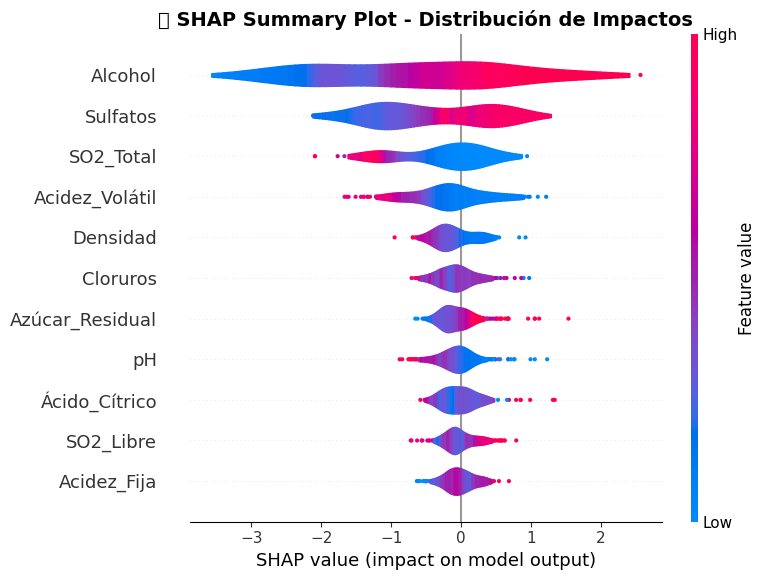

✅ Summary plot (violín) guardado como: shap_summary_violin.png


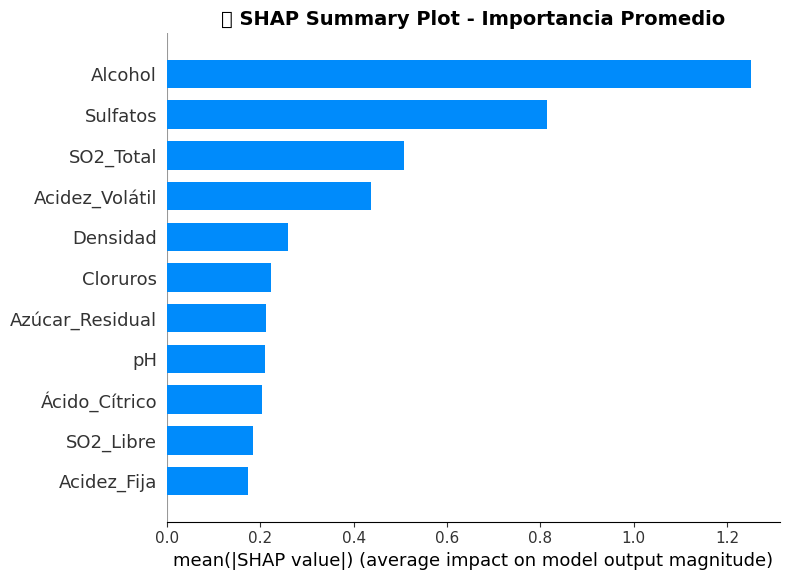

✅ Summary plot (barras) guardado como: shap_summary_bar.png



In [50]:
# ============================================================================
# 📊 1. SUMMARY PLOT - PANORAMA GLOBAL
# ============================================================================

print("📊 1. SUMMARY PLOT - Importancia Global de Features")
print("-" * 50)

# Summary plot tipo violín (muestra distribución de impactos)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="violin", show=False)
plt.title("🎻 SHAP Summary Plot - Distribución de Impactos", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_violin.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Summary plot (violín) guardado como: shap_summary_violin.png")

# Summary plot tipo barra (solo importancia promedio)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("📊 SHAP Summary Plot - Importancia Promedio", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Summary plot (barras) guardado como: shap_summary_bar.png")
print()

#### 🔍 ¿Cómo leer el Summary Plot?

El **Summary Plot tipo violín** combina importancia y dirección en un solo gráfico:

- **Eje Y (vertical)**: features ordenadas de más a menos importantes (de arriba a abajo).
- **Eje X (horizontal)**: valor SHAP → cuánto y en qué dirección contribuye cada feature a la predicción.
  - Valores **positivos (derecha)** → empujan la predicción hacia "alta calidad".
  - Valores **negativos (izquierda)** → empujan hacia "baja/media calidad".
- **Color de los puntos**: valor real de la feature en ese vino (rojo = alto, azul = bajo).

**Preguntas para reflexionar:**
- ¿Cuál es la feature más importante? ¿Tiene sentido desde un punto de vista enológico?
- ¿El alcohol alto (color rojo) produce SHAP positivo o negativo? ¿Qué nos dice eso?
- ¿Hay alguna feature donde el color y el SHAP van en direcciones contrarias? ¿Por qué puede pasar eso?


🌊 2. WATERFALL PLOTS - Explicaciones Paso a Paso
----------------------------------------------------
   🍷 Vino #21 (Alta Calidad - ✅ Correcto)
   Predicción: 0.880 | Real: Alta


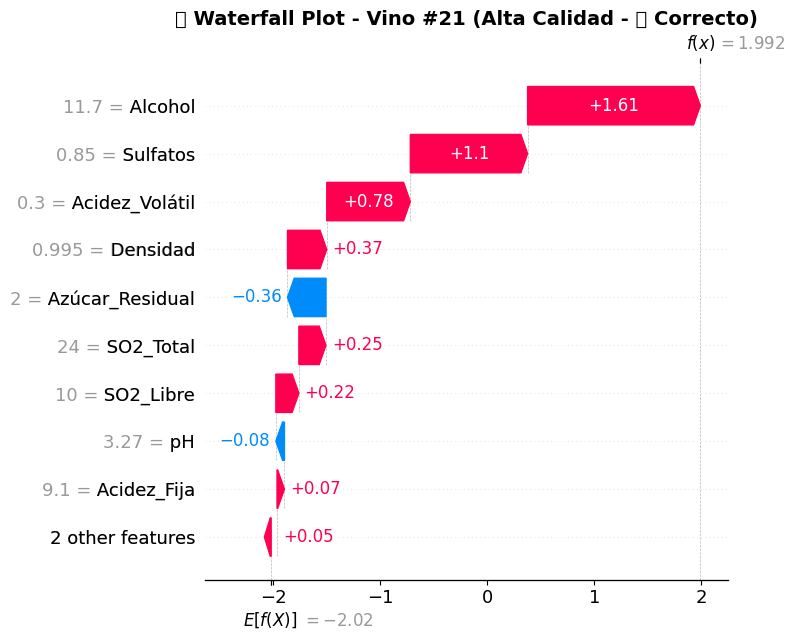

   ✅ Guardado como: waterfall_vino_21.png
   🍷 Vino #0 (Baja Calidad - ✅ Correcto)
   Predicción: 0.160 | Real: Baja/Media


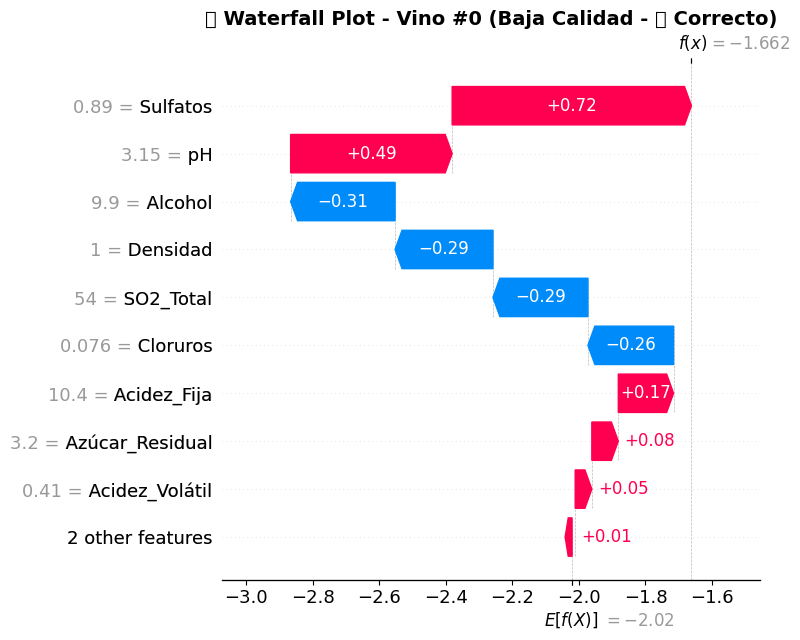

   ✅ Guardado como: waterfall_vino_0.png
   🍷 Vino #56 (❌ Error del Modelo)
   Predicción: 0.008 | Real: Alta


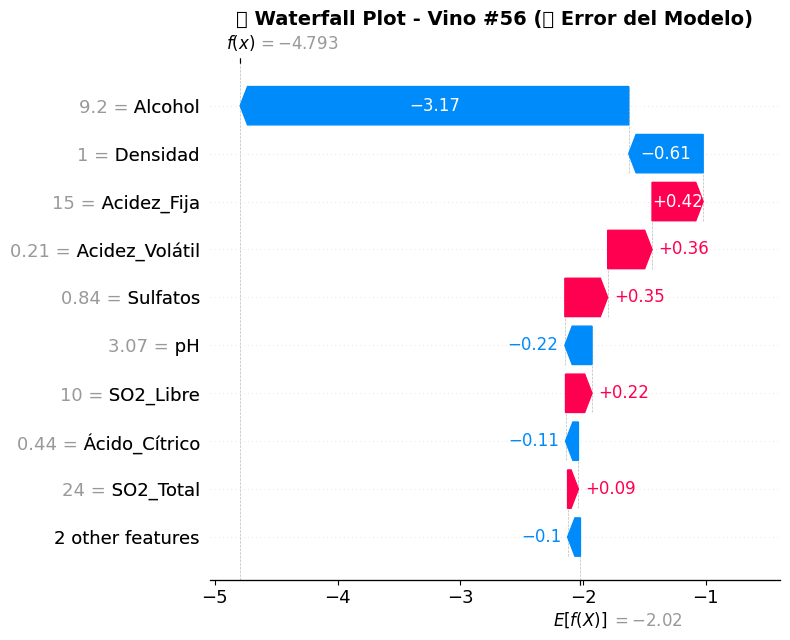

   ✅ Guardado como: waterfall_vino_56.png



In [51]:
# ============================================================================
# 🌊 2. WATERFALL PLOTS - EXPLICACIONES INDIVIDUALES
# ============================================================================

print("🌊 2. WATERFALL PLOTS - Explicaciones Paso a Paso")
print("-" * 52)

# Función para crear waterfall plots mejorados
def crear_waterfall_plot(sample_idx, titulo_extra=""):
    """Crea un waterfall plot para una muestra específica"""
    sample_data = X_test.iloc[sample_idx]
    sample_shap_vals = shap_values[sample_idx]
    sample_pred = y_proba[sample_idx]
    sample_real = y_test.iloc[sample_idx]

    print(f"   🍷 Vino #{sample_idx} {titulo_extra}")
    print(f"   Predicción: {sample_pred:.3f} | Real: {'Alta' if sample_real==1 else 'Baja/Media'}")

    # Waterfall plot usando shap
    plt.figure(figsize=(12, 6))

    # Crear explanation object para waterfall
    explanation = shap.Explanation(
        values=sample_shap_vals,
        base_values=explainer.expected_value,
        data=sample_data.values,
        feature_names=list(sample_data.index)
    )

    shap.waterfall_plot(explanation, show=False)
    plt.title(f"🌊 Waterfall Plot - Vino #{sample_idx} {titulo_extra}",
              fontsize=14, fontweight='bold')
    plt.tight_layout()

    filename = f'waterfall_vino_{sample_idx}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"   ✅ Guardado como: {filename}")
    return sample_pred, sample_real

# Crear waterfall para diferentes casos
# Caso 1: Predicción correcta de alta calidad
high_qual_correct = np.where((y_proba > 0.7) & (y_test == 1))[0]
if len(high_qual_correct) > 0:
    idx = high_qual_correct[0]
    crear_waterfall_plot(idx, "(Alta Calidad - ✅ Correcto)")

# Caso 2: Predicción correcta de baja calidad
low_qual_correct = np.where((y_proba < 0.3) & (y_test == 0))[0]
if len(low_qual_correct) > 0:
    idx = low_qual_correct[0]
    crear_waterfall_plot(idx, "(Baja Calidad - ✅ Correcto)")

# Caso 3: Error del modelo (si existe)
errors = np.where(((y_proba > 0.5) & (y_test == 0)) | ((y_proba < 0.5) & (y_test == 1)))[0]
if len(errors) > 0:
    idx = errors[0]
    crear_waterfall_plot(idx, "(❌ Error del Modelo)")

print()

#### 🔍 ¿Cómo leer el Waterfall Plot?

El **Waterfall Plot** muestra la "historia" de una predicción concreta, paso a paso:

- **Punto de partida (`E[f(X)]`)**: la predicción media del modelo si no supiéramos nada del vino (el baseline).
- **Cada barra**: contribución de una feature concreta.
  - Barra **roja (derecha)** → esa feature aumentó la probabilidad de alta calidad.
  - Barra **azul (izquierda)** → esa feature redujo la probabilidad.
- **Punto final (`f(x)`)**: la predicción final para ese vino concreto.

La suma de todas las barras + baseline = predicción final. Es matemáticamente exacto.

**Preguntas para reflexionar:**
- ¿Qué feature fue la más influyente en este vino concreto?
- ¿Coincide con la importancia global del Summary Plot, o hay diferencias?
- En el caso de error del modelo: ¿qué features "engañaron" al modelo?


⚡ 3. FORCE PLOTS - Visualización de Fuerzas
--------------------------------------------
   🎯 Force Plot - Vino #21 (Alta Calidad)


<Figure size 1400x300 with 0 Axes>

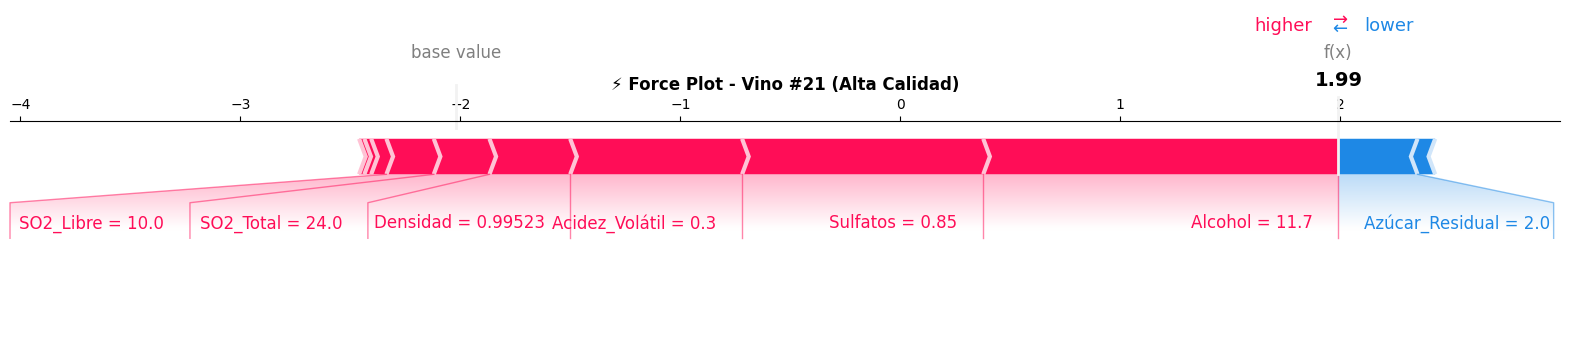

   ✅ Guardado como: force_plot_vino_21.png
   🎯 Force Plot - Vino #0 (Baja Calidad)


<Figure size 1400x300 with 0 Axes>

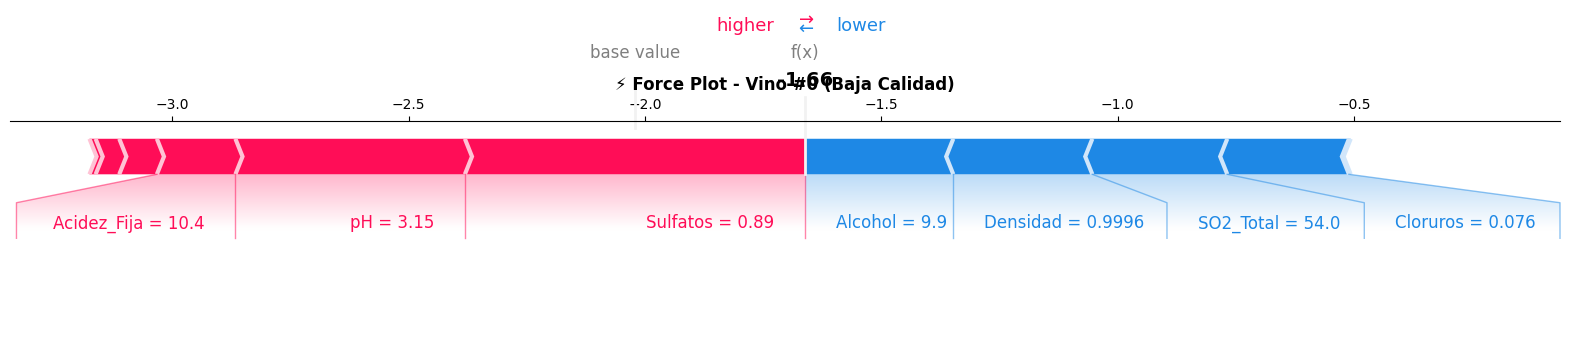

   ✅ Guardado como: force_plot_vino_0.png



In [52]:
# ============================================================================
# ⚡ 3. FORCE PLOTS - FUERZAS INDIVIDUALES
# ============================================================================

print("⚡ 3. FORCE PLOTS - Visualización de Fuerzas")
print("-" * 44)

# Función para crear force plot interpretable
def crear_force_plot(sample_idx, titulo_extra=""):
    """Crea un force plot para una muestra específica"""
    sample_data = X_test.iloc[sample_idx]
    sample_shap_vals = shap_values[sample_idx]
    sample_pred = y_proba[sample_idx]

    print(f"   🎯 Force Plot - Vino #{sample_idx} {titulo_extra}")

    # Force plot clásico
    plt.figure(figsize=(14, 3))
    shap.force_plot(
        explainer.expected_value,
        sample_shap_vals,
        sample_data,
        matplotlib=True,
        show=False
    )
    plt.title(f"⚡ Force Plot - Vino #{sample_idx} {titulo_extra}",
              fontsize=12, fontweight='bold')

    filename = f'force_plot_vino_{sample_idx}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"   ✅ Guardado como: {filename}")

# Crear force plots para los mismos casos
if len(high_qual_correct) > 0:
    crear_force_plot(high_qual_correct[0], "(Alta Calidad)")

if len(low_qual_correct) > 0:
    crear_force_plot(low_qual_correct[0], "(Baja Calidad)")

print()

#### 🔍 ¿Cómo leer el Force Plot?

El **Force Plot** muestra lo mismo que el Waterfall, pero de forma más compacta y visual:

- La **flecha roja** agrupa todas las features que empujan la predicción hacia "alta calidad".
- La **flecha azul** agrupa las que empujan hacia "baja/media calidad".
- El número final es la predicción del modelo para ese vino.
- El grosor de cada segmento es proporcional a su impacto (SHAP value).

Es especialmente útil para **presentar decisiones individuales a usuarios no técnicos**: en lugar de explicar el modelo en abstracto, explicamos por qué este vino concreto recibió esta puntuación.

**Preguntas para reflexionar:**
- ¿Cuál es la feature "ganadora" (más ancha en rojo o azul)?
- ¿Cómo explicarías al viticultor por qué su vino no fue clasificado como alta calidad?


🎯 4. PARTIAL DEPENDENCE PLOTS - Efecto de cada Feature
--------------------------------------------------------
   📈 Creando PDP para: Alcohol
   📈 Creando PDP para: Sulfatos
   📈 Creando PDP para: SO2_Total
   📈 Creando PDP para: Acidez_Volátil


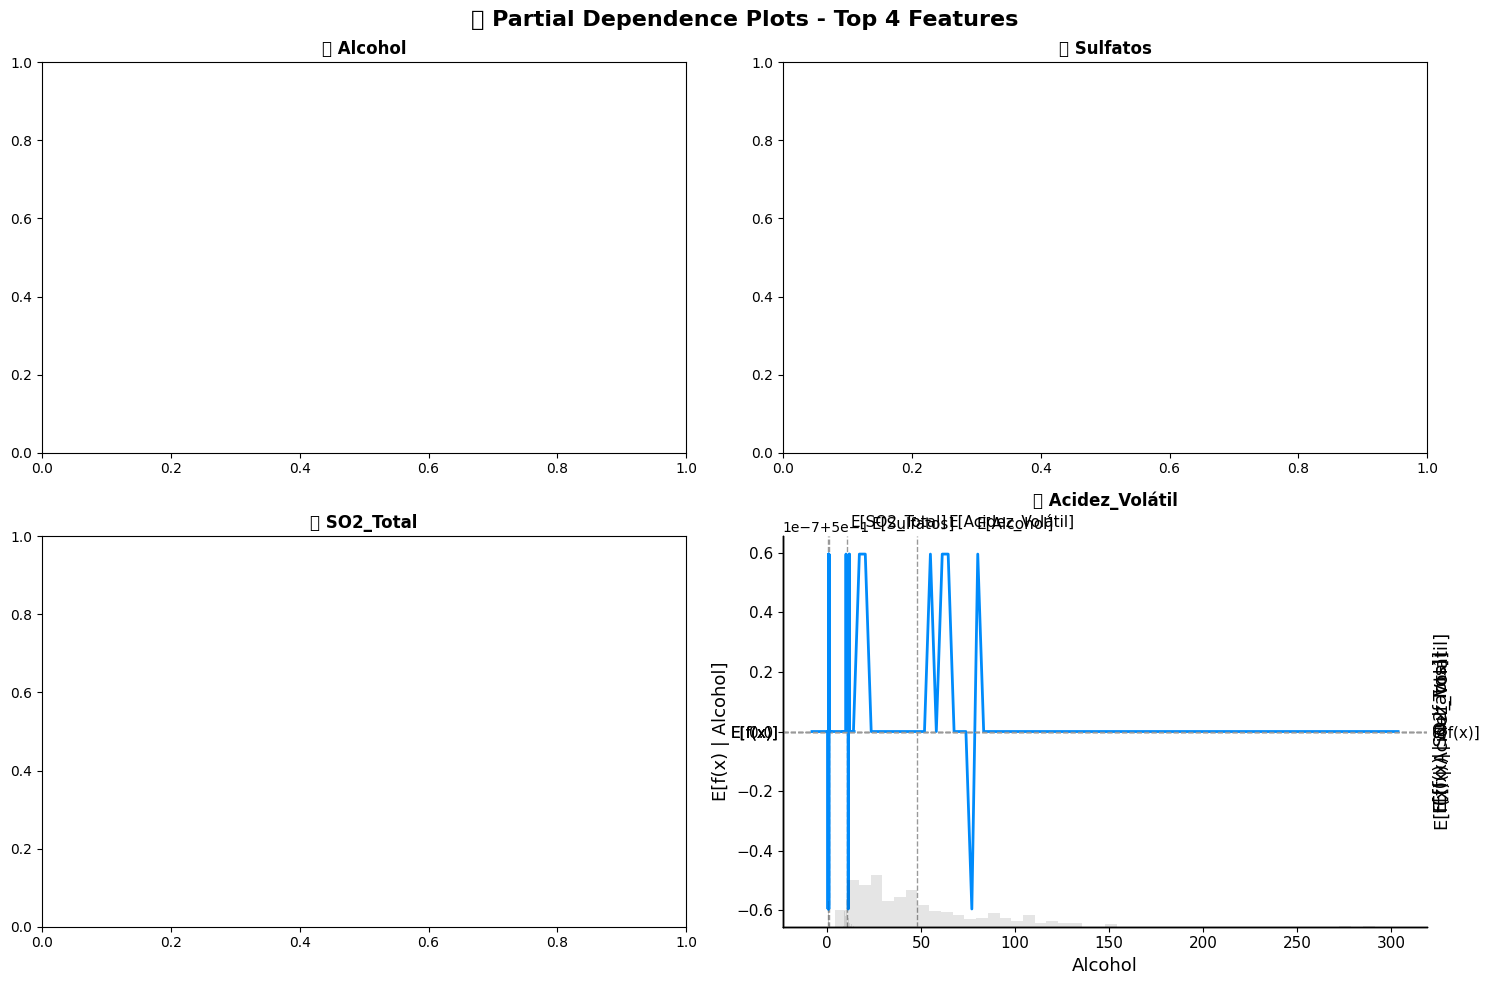

✅ PDPs guardados como: partial_dependence_plots.png



In [53]:
# ============================================================================
# 🎯 4. PARTIAL DEPENDENCE PLOTS - RELACIONES INDIVIDUALES
# ============================================================================

print("🎯 4. PARTIAL DEPENDENCE PLOTS - Efecto de cada Feature")
print("-" * 56)

# Top 4 features más importantes para PDPs
top_features = shap_importance_df.head(4)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    print(f"   📈 Creando PDP para: {feature}")

    # Partial dependence plot
    feature_idx = list(X_test.columns).index(feature)
    shap.partial_dependence_plot(
        feature_idx, model.predict_proba, X_test, ice=False,
        model_expected_value=True, feature_expected_value=True,
        ax=axes[i], show=False
    )
    axes[i].set_title(f"📈 {feature}", fontweight='bold')

plt.suptitle("🎯 Partial Dependence Plots - Top 4 Features", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('partial_dependence_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ PDPs guardados como: partial_dependence_plots.png")
print()

#### 🔍 ¿Cómo leer los Partial Dependence Plots (PDP)?

Los **PDP** muestran la relación promedio entre una feature y la predicción del modelo, manteniendo el resto de features constantes:

- **Eje X**: valor de la feature (p.ej. nivel de alcohol del 8% al 14%).
- **Eje Y**: probabilidad media predicha de "alta calidad".
- La **línea** muestra la tendencia general.

A diferencia de SHAP (que dice cuánto contribuye cada feature en cada predicción individual), los PDP muestran el **efecto medio global** de cada variable.

**Preguntas para reflexionar:**
- ¿La relación entre alcohol y calidad es lineal, o hay un punto de inflexión?
- ¿Hay alguna feature donde un valor extremo alto o bajo sea claramente perjudicial?
- ¿Por qué puede ser útil este gráfico para un viticultor que quiere mejorar su vino?


🔥 5. HEATMAP - Patrones en SHAP Values
----------------------------------------


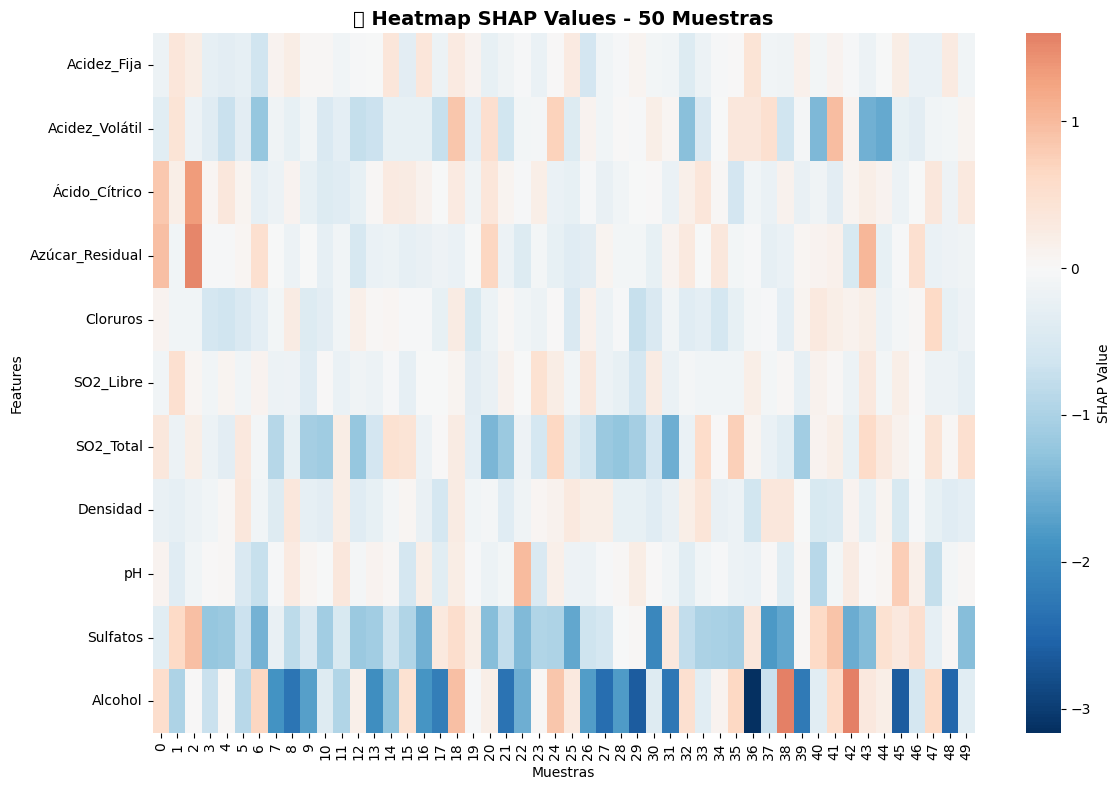

✅ Heatmap guardado como: shap_heatmap.png



In [54]:
# ============================================================================
# 🔥 5. HEATMAP DE SHAP VALUES
# ============================================================================

print("🔥 5. HEATMAP - Patrones en SHAP Values")
print("-" * 40)

# Seleccionar una muestra de observaciones para el heatmap
n_samples_heatmap = min(50, len(X_test))  # Máximo 50 para legibilidad
sample_indices = np.random.choice(len(X_test), n_samples_heatmap, replace=False)

# Crear heatmap
plt.figure(figsize=(12, 8))
shap_heatmap_data = shap_values[sample_indices]

# Heatmap de SHAP values
sns.heatmap(
    shap_heatmap_data.T,  # Transponer para features en filas
    yticklabels=X_test.columns,
    cmap='RdBu_r',  # Rojo-Azul invertido
    center=0,  # Centrar en 0
    cbar_kws={'label': 'SHAP Value'}
)

plt.title(f"🔥 Heatmap SHAP Values - {n_samples_heatmap} Muestras", fontsize=14, fontweight='bold')
plt.xlabel("Muestras")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig('shap_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Heatmap guardado como: shap_heatmap.png")
print()

#### 🔍 ¿Cómo leer el Heatmap de SHAP Values?

El **Heatmap** muestra los SHAP values de múltiples muestras a la vez:

- **Filas**: cada feature (variable del vino).
- **Columnas**: cada vino del conjunto de test (muestra).
- **Color**:
  - **Rojo** → SHAP positivo (esa feature aumenta la probabilidad de alta calidad en ese vino).
  - **Azul** → SHAP negativo (esa feature reduce la probabilidad).
  - **Blanco** → impacto neutro.

Es útil para detectar **patrones globales**: si toda una fila es roja, esa feature siempre empuja en la misma dirección. Si hay mezcla, su efecto depende del contexto del vino.

**Preguntas para reflexionar:**
- ¿Hay alguna feature que sea consistentemente roja (siempre aumenta la calidad) o azul (siempre la reduce)?
- ¿Puedes identificar columnas (vinos) con muchos valores rojos? ¿Qué predijo el modelo para ellos?


🎪 6. DECISION PLOT - Camino de Decisión del Modelo
--------------------------------------------------


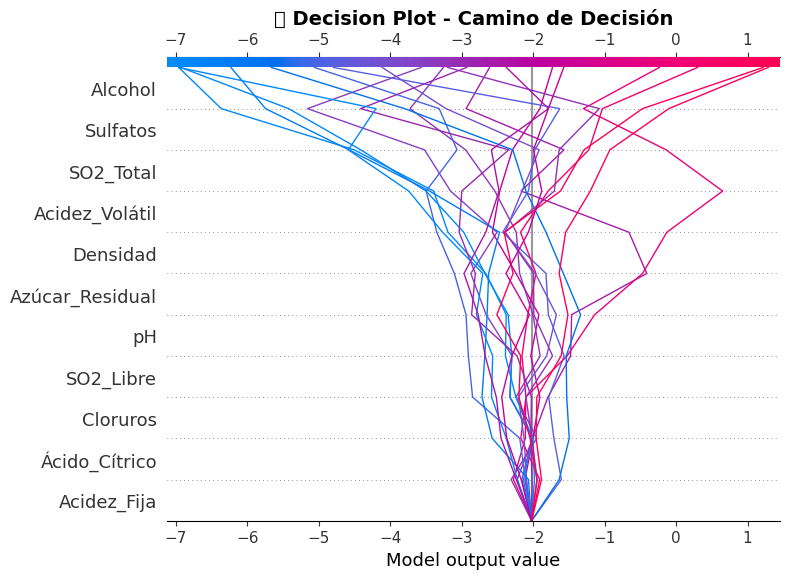

✅ Decision plot guardado como: decision_plot.png



In [55]:
# ============================================================================
# 🎪 6. DECISION PLOT - CAMINO DE DECISIÓN
# ============================================================================

print("🎪 6. DECISION PLOT - Camino de Decisión del Modelo")
print("-" * 50)

# Decision plot para algunas muestras
sample_size = min(20, len(X_test))
sample_idx = np.random.choice(len(X_test), sample_size, replace=False)

plt.figure(figsize=(10, 8))
shap.decision_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    show=False
)
plt.title("🎪 Decision Plot - Camino de Decisión", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Decision plot guardado como: decision_plot.png")
print()

#### 🔍 ¿Cómo leer el Decision Plot?

El **Decision Plot** muestra el "camino" que sigue el modelo desde el baseline hasta la predicción final para varias muestras a la vez:

- Cada línea es un vino diferente.
- El eje X muestra el valor acumulado de la predicción (empieza en el baseline).
- Cada feature "tuerce" la línea a la derecha (aumenta probabilidad) o a la izquierda (la reduce).
- Al final, la posición de cada línea es la predicción final de ese vino.

Es útil para ver si hay **grupos de vinos** que siguen caminos similares, y para identificar en qué punto se separan las predicciones altas de las bajas.

**Preguntas para reflexionar:**
- ¿En qué features se separan más los caminos de los distintos vinos?
- ¿Hay alguna feature donde prácticamente todas las líneas van en la misma dirección?


📊 7. BEESWARM PLOT - Distribución Detallada de Impactos
-------------------------------------------------------


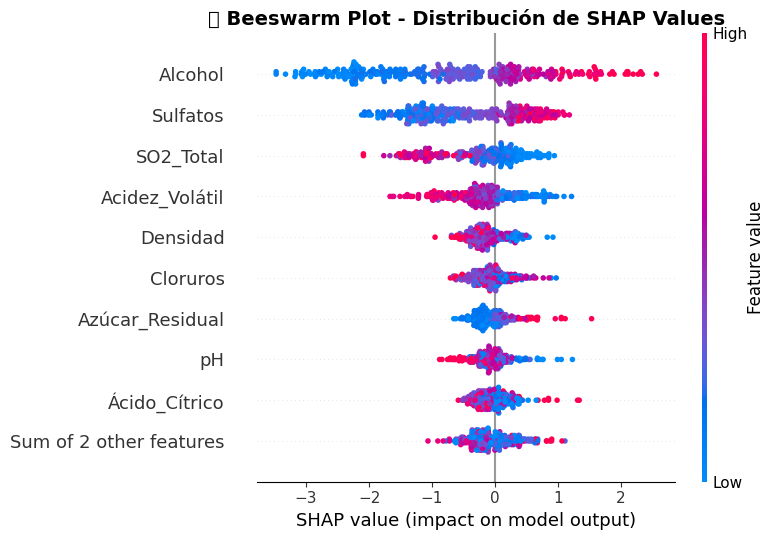

✅ Beeswarm plot guardado como: beeswarm_plot.png



In [56]:
# ============================================================================
# 📊 7. BEESWARM PLOT - DISTRIBUCIÓN DETALLADA
# ============================================================================

print("📊 7. BEESWARM PLOT - Distribución Detallada de Impactos")
print("-" * 55)

plt.figure(figsize=(12, 8))
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values,
        base_values=explainer.expected_value,
        data=X_test.values,
        feature_names=list(X_test.columns)
    ),
    show=False
)
plt.title("📊 Beeswarm Plot - Distribución de SHAP Values", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('beeswarm_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Beeswarm plot guardado como: beeswarm_plot.png")
print()

#### 🔍 ¿Cómo leer el Beeswarm Plot?

El **Beeswarm Plot** es similar al Summary Plot pero muestra cada vino como un punto individual (sin agregar en violín):

- **Eje Y**: features ordenadas de más a menos importantes.
- **Eje X**: valor SHAP de ese vino para esa feature.
- **Color**: valor real de la feature en ese vino (rojo = alto, azul = bajo).
- Los puntos se "dispersan" verticalmente para evitar solapamientos (de ahí el nombre "beeswarm", enjambre de abejas).

Es más detallado que el Summary Plot: podemos ver si hay **outliers** (puntos muy alejados del resto) o si la distribución es uniforme.

**Preguntas para reflexionar:**
- ¿Hay features con una distribución de SHAP muy concentrada cerca de 0? ¿Qué significa?
- ¿Hay algún vino (punto) con un SHAP extremadamente alto o bajo? ¿Qué tiene de especial?
- ¿El Beeswarm añade información respecto al Summary Plot violín, o cuentan la misma historia?


In [57]:
# ============================================================================
# 🎨 8. RESUMEN DE VISUALIZACIONES CREADAS
# ============================================================================

print("🎨 RESUMEN DE VISUALIZACIONES CREADAS:")
print("=" * 40)

visualizations = [
    "📊 shap_summary_violin.png - Distribución global de impactos",
    "📊 shap_summary_bar.png - Importancia promedio por feature",
    "🌊 waterfall_vino_*.png - Explicaciones paso a paso individuales",
    "⚡ force_plot_vino_*.png - Fuerzas que empujan cada decisión",
    "🎯 partial_dependence_plots.png - Efecto individual de top features",
    "🔥 shap_heatmap.png - Patrones de SHAP values en múltiples muestras",
    "🎪 decision_plot.png - Camino de decisión del modelo",
    "📊 beeswarm_plot.png - Distribución detallada de impactos"
]

for viz in visualizations:
    print(f"   ✅ {viz}")

print()
print("💡 CÓMO INTERPRETAR CADA VISUALIZACIÓN:")
print("-" * 40)

interpretations = {
    "📊 Summary Plot (Violín)": "Muestra la distribución de impactos de cada feature. Ancho = frecuencia, color = valor del feature",
    "📊 Summary Plot (Barras)": "Ranking simple de importancia promedio. Más largo = más importante",
    "🌊 Waterfall Plot": "Cómo cada feature empuja la predicción desde baseline hasta resultado final",
    "⚡ Force Plot": "Visualiza 'fuerzas' rojas (hacia 0) vs azules (hacia 1) para una predicción",
    "🎯 Partial Dependence": "Cómo cambia la predicción cuando varía una sola feature",
    "🔥 Heatmap": "Patrones de SHAP values: rojo = empuja hacia 0, azul = empuja hacia 1",
    "🎪 Decision Plot": "Camino que sigue el modelo desde baseline hasta predicción final",
    "📊 Beeswarm": "Como summary plot pero muestra cada punto individual (mejor para patrones)"
}

for viz, explanation in interpretations.items():
    print(f"\n{viz}:")
    print(f"   {explanation}")

print()

🎨 RESUMEN DE VISUALIZACIONES CREADAS:
   ✅ 📊 shap_summary_violin.png - Distribución global de impactos
   ✅ 📊 shap_summary_bar.png - Importancia promedio por feature
   ✅ 🌊 waterfall_vino_*.png - Explicaciones paso a paso individuales
   ✅ ⚡ force_plot_vino_*.png - Fuerzas que empujan cada decisión
   ✅ 🎯 partial_dependence_plots.png - Efecto individual de top features
   ✅ 🔥 shap_heatmap.png - Patrones de SHAP values en múltiples muestras
   ✅ 🎪 decision_plot.png - Camino de decisión del modelo
   ✅ 📊 beeswarm_plot.png - Distribución detallada de impactos

💡 CÓMO INTERPRETAR CADA VISUALIZACIÓN:
----------------------------------------

📊 Summary Plot (Violín):
   Muestra la distribución de impactos de cada feature. Ancho = frecuencia, color = valor del feature

📊 Summary Plot (Barras):
   Ranking simple de importancia promedio. Más largo = más importante

🌊 Waterfall Plot:
   Cómo cada feature empuja la predicción desde baseline hasta resultado final

⚡ Force Plot:
   Visualiza 'fuerz

In [58]:
# ============================================================================
# 🎯 9. FUNCIÓN PARA EXPLICAR VISUALMENTE CUALQUIER VINO
# ============================================================================

def explicar_vino_visual(wine_index):
    """
    Crea todas las visualizaciones para un vino específico
    """
    if wine_index >= len(X_test):
        print(f"❌ Índice fuera de rango. Máximo: {len(X_test)-1}")
        return

    print(f"🍷 ANÁLISIS VISUAL COMPLETO - VINO #{wine_index}")
    print("=" * 50)

    # Datos básicos
    sample_data = X_test.iloc[wine_index]
    sample_shap_vals = shap_values[wine_index]
    sample_pred = y_proba[wine_index]
    sample_real = y_test.iloc[wine_index]

    print(f"Predicción: {sample_pred:.3f} ({sample_pred*100:.1f}%)")
    print(f"Real: {'Alta calidad' if sample_real == 1 else 'Baja/media calidad'}")
    print(f"Estado: {'✅ Correcto' if (sample_pred > 0.5) == sample_real else '❌ Incorrecto'}")
    print()

    # 1. Waterfall plot
    plt.figure(figsize=(12, 6))
    explanation = shap.Explanation(
        values=sample_shap_vals,
        base_values=explainer.expected_value,
        data=sample_data.values,
        feature_names=list(sample_data.index)
    )
    shap.waterfall_plot(explanation, show=False)
    plt.title(f"🌊 Waterfall - Vino #{wine_index}", fontweight='bold')
    plt.tight_layout()
    plt.show()

    # 2. Force plot
    plt.figure(figsize=(14, 3))
    shap.force_plot(
        explainer.expected_value,
        sample_shap_vals,
        sample_data,
        matplotlib=True,
        show=False
    )
    plt.title(f"⚡ Force Plot - Vino #{wine_index}", fontweight='bold')
    plt.tight_layout()
    plt.show()

    # 3. Tabla resumen
    contributions = pd.DataFrame({
        'Feature': sample_data.index,
        'Valor': sample_data.values,
        'SHAP': sample_shap_vals,
        'Impacto': ['📈 Positivo' if x > 0 else '📉 Negativo' if x < 0 else '➖ Neutral' for x in sample_shap_vals]
    }).round(3)

    contributions['SHAP_Abs'] = abs(contributions['SHAP'])
    contributions = contributions.sort_values('SHAP_Abs', ascending=False).drop('SHAP_Abs', axis=1)

    print("📋 TABLA RESUMEN:")
    print(contributions.to_string(index=False))

    return contributions

print("🎁 FUNCIÓN PARA ANÁLISIS VISUAL COMPLETO:")
print("   explicar_vino_visual(indice)")
print("   Ejemplo: explicar_vino_visual(0)")
print()

print("🎉 ¡VISUALIZACIONES SHAP COMPLETAS!")
print("=" * 35)
print("✅ 8 tipos diferentes de gráficos creados")
print("✅ Múltiples perspectivas del mismo modelo")
print("✅ Archivos PNG guardados para presentaciones")
print("✅ Función interactiva para explorar cualquier caso")
print()
print("🚀 ¡Ahora tienes explicabilidad VISUAL completa!")
print("   Cada gráfico cuenta una parte diferente de la historia")
print("   Combínalos para obtener insights profundos")

🎁 FUNCIÓN PARA ANÁLISIS VISUAL COMPLETO:
   explicar_vino_visual(indice)
   Ejemplo: explicar_vino_visual(0)

🎉 ¡VISUALIZACIONES SHAP COMPLETAS!
✅ 8 tipos diferentes de gráficos creados
✅ Múltiples perspectivas del mismo modelo
✅ Archivos PNG guardados para presentaciones
✅ Función interactiva para explorar cualquier caso

🚀 ¡Ahora tienes explicabilidad VISUAL completa!
   Cada gráfico cuenta una parte diferente de la historia
   Combínalos para obtener insights profundos


### Conclusión

Resumen

In [59]:
# ============================================================================
# 📈 PASO 11: RESUMEN EJECUTIVO
# ============================================================================

print("📈 RESUMEN EJECUTIVO:")
print("=" * 25)

print(f"🍷 Dataset: {X.shape[0]} vinos, {X.shape[1]} características")
print(f"🎯 Problema: Clasificar vinos de alta vs baja/media calidad")
print(f"🚀 Modelo: XGBoost con {accuracy*100:.1f}% de precisión")
print()

print("🏆 TOP 3 FACTORES MÁS IMPORTANTES (según SHAP):")
for i, row in shap_importance_df.head(3).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Mean_SHAP_Importance']:.3f}")
print()

print("💡 INSIGHTS CLAVE:")
print(f"   • El modelo funciona {'bien' if accuracy > 0.8 else 'decentemente' if accuracy > 0.7 else 'regular'}")
print("   • SHAP nos permite explicar cada decisión individual")
print("   • Podemos identificar por qué el modelo se equivoca")
print("   • Transparencia total: sabemos qué influye en cada predicción")
print()

print("🎯 PRÓXIMOS PASOS SUGERIDOS:")
print("   1. Crear gráficos SHAP (waterfall, summary, force plots)")
print("   2. Analizar patrones en casos incorrectos")
print("   3. Optimizar modelo basándose en insights de SHAP")
print("   4. Implementar explicaciones automáticas para usuarios finales")

# ============================================================================
# 🎨 CÓDIGO BONUS: FUNCIÓN PARA EXPLICAR CUALQUIER VINO
# ============================================================================

def explicar_vino(wine_index, detailed=True):
    """
    Función para explicar la predicción de cualquier vino del dataset de test

    Args:
        wine_index (int): Índice del vino en el conjunto de test
        detailed (bool): Si mostrar explicación detallada
    """
    if wine_index >= len(X_test):
        print(f"❌ Índice {wine_index} fuera de rango. Máximo: {len(X_test)-1}")
        return

    # Obtener datos
    sample = X_test.iloc[wine_index]
    shap_vals = shap_values[wine_index]
    prediction = y_proba[wine_index]
    real_value = y_test.iloc[wine_index]

    print(f"🍷 EXPLICACIÓN VINO #{wine_index}")
    print("-" * 30)
    print(f"Predicción: {prediction:.3f} ({'Alta calidad' if prediction > 0.5 else 'Baja/media calidad'})")
    print(f"Real: {'Alta calidad' if real_value == 1 else 'Baja/media calidad'}")
    print(f"Correcto: {'✅' if (prediction > 0.5) == real_value else '❌'}")

    if detailed:
        print(f"\nBaseline: {explainer.expected_value:.3f}")
        print("Contribuciones:")
        for feature, shap_val, feature_val in zip(feature_names, shap_vals, sample):
            direction = "↗️" if shap_val > 0 else "↘️"
            print(f"  {direction} {feature}: {feature_val:.3f} → {shap_val:+.3f}")

    return {
        'prediction': prediction,
        'real': real_value,
        'shap_values': shap_vals,
        'features': sample
    }


print("¡Ahora puedes responder al 'por qué' detrás de cada predicción!")

📈 RESUMEN EJECUTIVO:
🍷 Dataset: 1599 vinos, 11 características
🎯 Problema: Clasificar vinos de alta vs baja/media calidad
🚀 Modelo: XGBoost con 94.4% de precisión

🏆 TOP 3 FACTORES MÁS IMPORTANTES (según SHAP):
   11. Alcohol: 1.251
   10. Sulfatos: 0.814
   7. SO2_Total: 0.508

💡 INSIGHTS CLAVE:
   • El modelo funciona bien
   • SHAP nos permite explicar cada decisión individual
   • Podemos identificar por qué el modelo se equivoca
   • Transparencia total: sabemos qué influye en cada predicción

🎯 PRÓXIMOS PASOS SUGERIDOS:
   1. Crear gráficos SHAP (waterfall, summary, force plots)
   2. Analizar patrones en casos incorrectos
   3. Optimizar modelo basándose en insights de SHAP
   4. Implementar explicaciones automáticas para usuarios finales
¡Ahora puedes responder al 'por qué' detrás de cada predicción!
